Fricano Emanuela 1152359

Giraudo Carlotta 975787


## **Objective of the project**
In this project we are going to perform some **clustering** techniques on the *Mushroom Classification* dataset. This dataset contains more than 8000 samples about mushrooms, describing their characteristics, such as color or odor, and classifying them as poisonous or edible.
We will use these labels to assess the validity of our methods.

## **0 Preprocessing**

Notice that the preprocessing step is common for both the classification and clustering tasks. Some observations may be relevant to just one of them, nonetheless are presented in both notebooks.

In this first part, the focus is on **data preprocessing**. The main objective is to transform the original dataset into a numerical and consistent format, without using any prior information about the target variable.

The dataset contains a variable called `class`, which indicates whether a mushroom is *edible* or *poisonous*. This variable represents the ground truth label.



## 0.1 Import of Libraries

We import the Python libraries we will use in this project.

- **pandas** and **numpy** are used for data manipulation and numerical operations;
- **matplotlib** and **seaborn** are used for basic data visualization;
- **math** for mathematical operations;
- **OneHotEncoder** is used for treating the nominal features;
- **StandardScaler** will be used to normalize the data;
- **OrdinalEncoder** is used to transform the ordinal features;
- **PCA** will be used to represent visually the clusters in 2D;
- **train_test_split** is used to create the training and testing sets, useful for classification evaluation.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split



## 0.2 Loading the Dataset

We load the Mushroom Classification dataset.
Each row represents a single mushroom, while each column corresponds to a specific attribute describing its characteristics.

The dataset is composed of categorical variables encoded as single characters, representing the initial of the type of the attribute, according to the official UCI data description.


In [9]:
import kagglehub
import os

path = kagglehub.dataset_download("uciml/mushroom-classification")
df = pd.read_csv(path + "/mushrooms.csv")
df.head()


Using Colab cache for faster access to the 'mushroom-classification' dataset.


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### 0.3 Dataset Dimensions and Structure

In order to better understand the structure of the data, we first analyze the size and the general information of the dataset.
The dataset contains **8,124 observations** and **23 variables**.

In [10]:
df.shape


(8124, 23)

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

### 0.4 Overview of the Variables

The dataset includes one target variable, called `class`, and several explanatory variables describing mushroom characteristics such as cap shape, odor, gill properties, stalk features, and habitat.


In [12]:
df.columns


Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')


Below is a description of each variable included in the dataset.
- **class**: Indicates whether the mushroom is edible or poisonous  
  - *e* = edible  
  - *p* = poisonous  
- **cap-shape**: Shape of the mushroom cap (e.g. bell, conical, convex, flat)
- **cap-surface**: Surface texture of the cap (e.g. smooth, scaly, fibrous)
- **cap-color**: Color of the cap (e.g. brown, yellow, white, red)
- **bruises**: Indicates whether bruises are present on the mushroom
- **odor**: Smell of the mushroom (e.g. almond, anise, foul, none)
- **gill-attachment**: How the gills are attached to the stalk
- **gill-spacing**: Distance between gills (close or crowded)
- **gill-size**: Size of the gills (broad or narrow)
- **gill-color**: Color of the gills
- **stalk-shape**: Shape of the stalk (enlarging or tapering)
- **stalk-root**: Shape of the stalk root  
- **stalk-surface-above-ring**: Surface texture of the stalk above the ring
- **stalk-surface-below-ring**: Surface texture of the stalk below the ring
- **stalk-color-above-ring**: Color of the stalk above the ring
- **stalk-color-below-ring**: Color of the stalk below the ring
- **veil-type**: Type of veil covering the mushroom
- **veil-color**: Color of the veil
- **ring-number**: Number of rings on the stalk
- **ring-type**: Type of ring
- **spore-print-color**: Color of the spore print
- **population**: Population density of mushrooms in the area
- **habitat**: Natural habitat where the mushroom grows

All these variables are categorical and mostly nominal, therefore a suitable encoding method is required before applying clustering algorithms based on distance measures.
By the documentation found on Kaggle, we know that the variable **stalk-root**  may contain the symbol '?' indicating missing or unknown values.




##0.5 Countplots of Variables
In this section, we explore the distribution of all the categorical variables using countplots. Since they are categorical, it is not necessary to study their histograms or scatterplot.
The goal is to observe how different categories are represented in the dataset and to identify possible dominant or rare categories.
The countplot of the variable class in this analysis is only descriptive and not used in clustering.

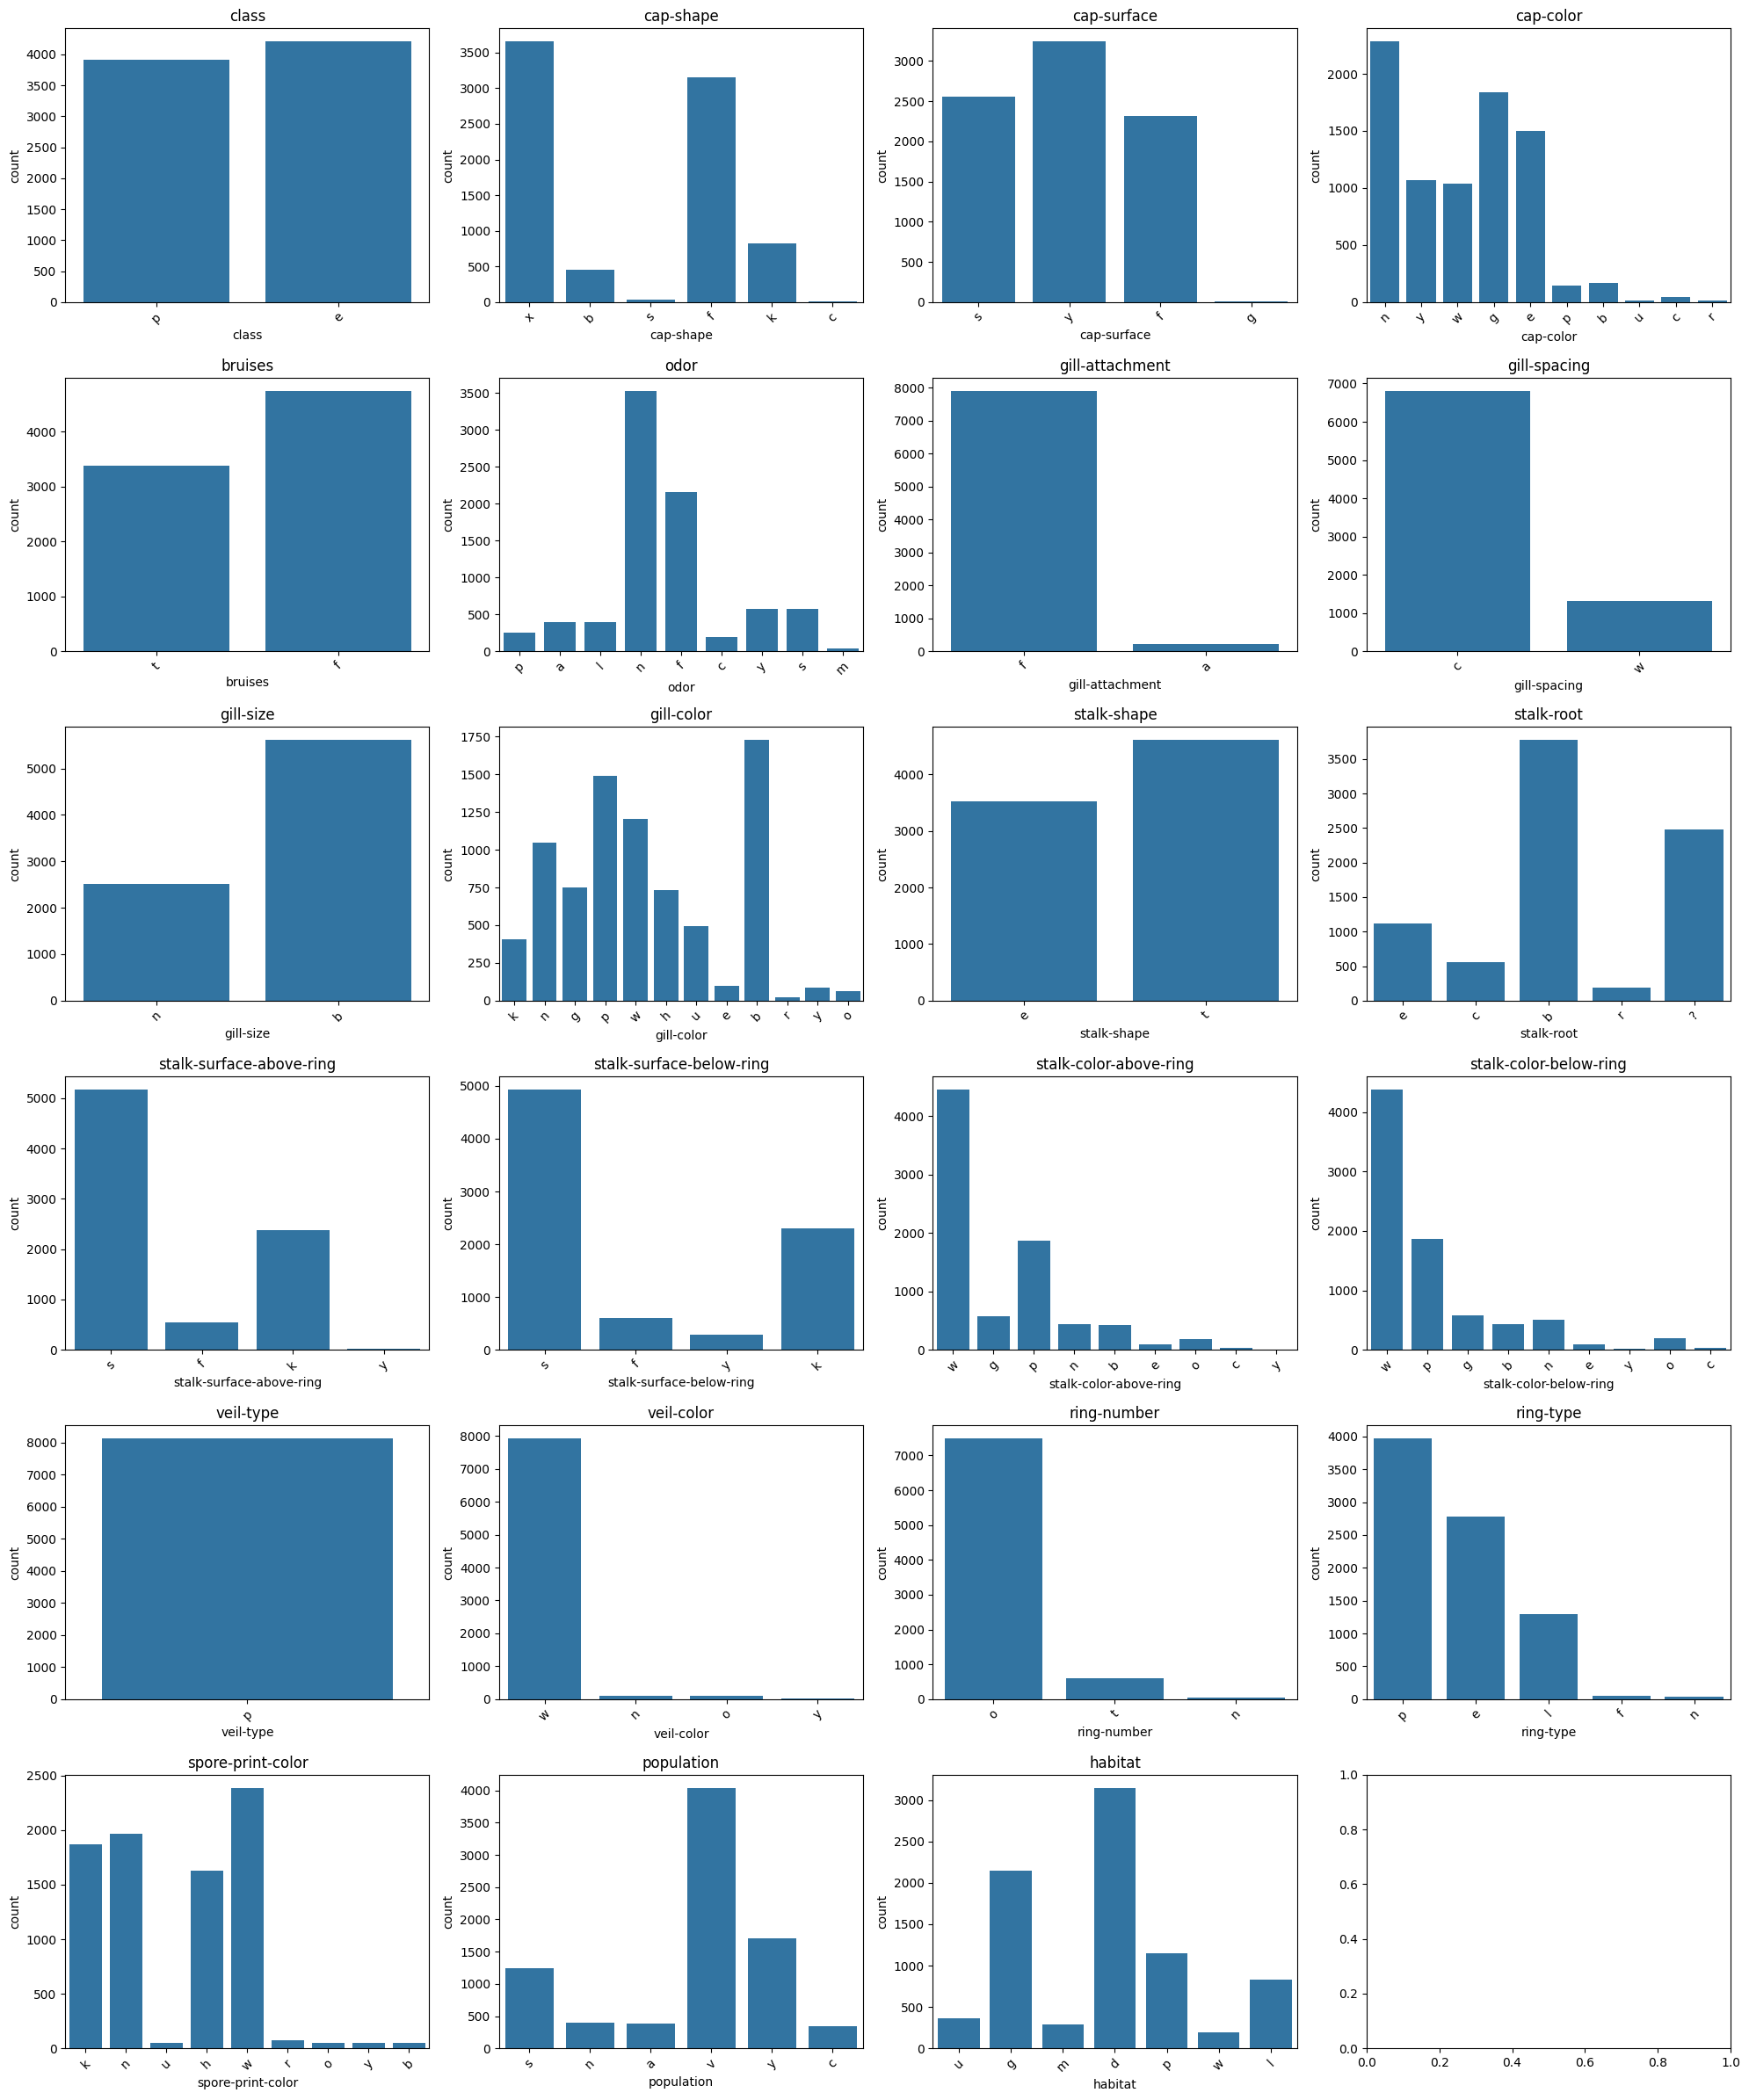

In [13]:
categorical_cols = df.columns
n_features = len(categorical_cols)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Let us analize some of these countplots.

For the target variable `class`, which distinguishes between edible (`e`) and poisonous (`p`) mushrooms, we can say that the two classes appear to be relatively balanced in terms of frequency.  
This indicates that the dataset does not present a strong class imbalance.
A slight difference between the two classes can be observed, with edible mushrooms being marginally more frequent.

Some kinds of cap color appear much more frequently than others.  
In particular, the categories `n`, `g`, and `e` are among the most common, while several colors occur only rarely.
This indicates that the distribution of cap color is uneven, with a clear dominance of a few categories.  
Such a pattern suggests that `cap-color` may provide useful information, although some categories contribute only marginally to the overall dataset.

About `odor` most mushrooms belong to the “no odor” category.
Some odor categories may be strongly associated with specific mushroom types.

Several gill colors show relatively high frequencies, while others are much less common.  
The distribution is more spread compared to cap color, indicating greater variability across categories.
This suggests that `gill-color` captures a wider range of values and may contain relevant information for distinguishing different mushroom types.

It is interesting to observe that the variable `veil-type` has only one observed value across all samples.
Since this feature shows no variability, it does not contribute to distance computations and can be safely removed during preprocessing. Anyway we decided to keep it.

##0.6 Relationship between Features and the Target Variable

In this section, we perform an exploratory supervised analysis to investigate the relationship between some selected categorical features and the target variable class.
The objective is to understand how the distribution of feature categories differs between edible and poisonous mushrooms, and to identify variables that may be informative for classification.
It is important to note that this analysis is purely descriptive and is not used during the clustering phase. The target variable is considered here only to gain insights into the data and to support later interpretation of the clustering and classification results.

### Relationship between Odor and Class

The countplot shows the distribution of the variable `odor` across the two mushroom classes.


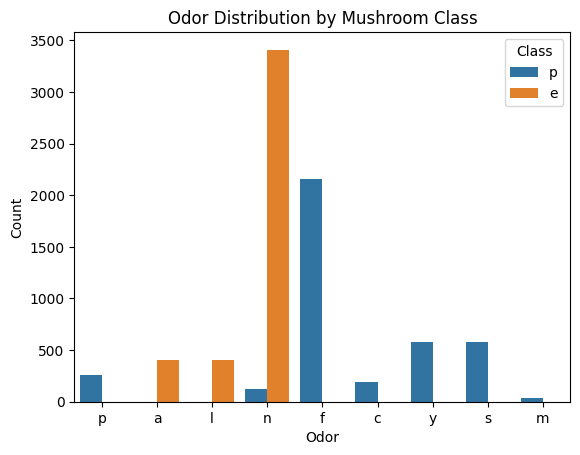

In [14]:
sns.countplot(x="odor", hue="class", data=df)

plt.title("Odor Distribution by Mushroom Class")
plt.xlabel("Odor")
plt.ylabel("Count")
plt.legend(title="Class")
plt.show()



Mushrooms with no odor (`n`) are predominantly edible, while foul odor (`f`) is mainly associated with poisonous mushrooms.  
Several odor categories appear almost exclusively in one class, indicating a strong separation between edible and poisonous mushrooms based on odor, as we noticed in the previous section.
This pattern suggests a clear association between odor and the target variable class.

### Relationship between Cap Color and Class

The countplot shows the distribution of `cap-color` across edible and poisonous mushrooms.


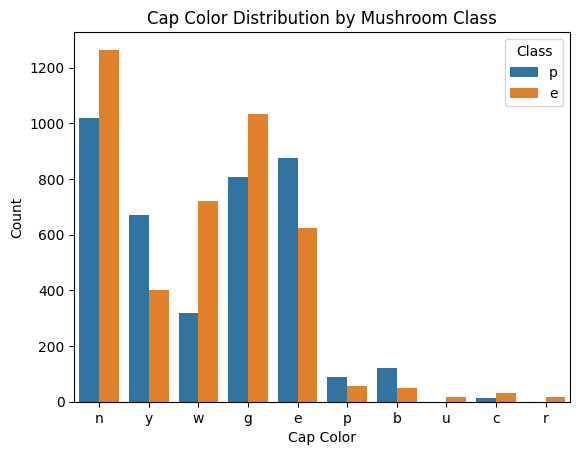

In [15]:
sns.countplot(x="cap-color", hue="class", data=df)

plt.title("Cap Color Distribution by Mushroom Class")
plt.xlabel("Cap Color")
plt.ylabel("Count")
plt.legend(title="Class")
plt.show()



For most cap colors, both classes are present, and no single color appears to be exclusively associated with one class, apart from r and u which are very rare even for their own class.  
Some colors show differences in frequency between edible and poisonous mushrooms, but the overlap between the two classes remains substantial.
Compared to the odor variable, cap color does not provide a clear separation among classes.


## 0.7 Correlation Matrix of Encoded Features

The correlation matrix shows the pairwise correlations between the one-hot encoded features.

Most correlations are close to zero, indicating a low linear dependence between the majority of encoded variables.
This result is expected, as one-hot encoding produces binary features that represent mutually exclusive categories within the same original variable.

Some localized blocks of higher positive or negative correlation can be observed.
These patterns mainly arise from the encoding structure itself, where categories belonging to the same original feature are necessarily related, but can also come from correlated features (think about the association between odor and class seen before).

Overall, the correlation matrix does not reveal strong linear relationships between features.
Its main purpose is to provide a global overview of the encoded data structure and to highlight the absence of widespread multicollinearity.



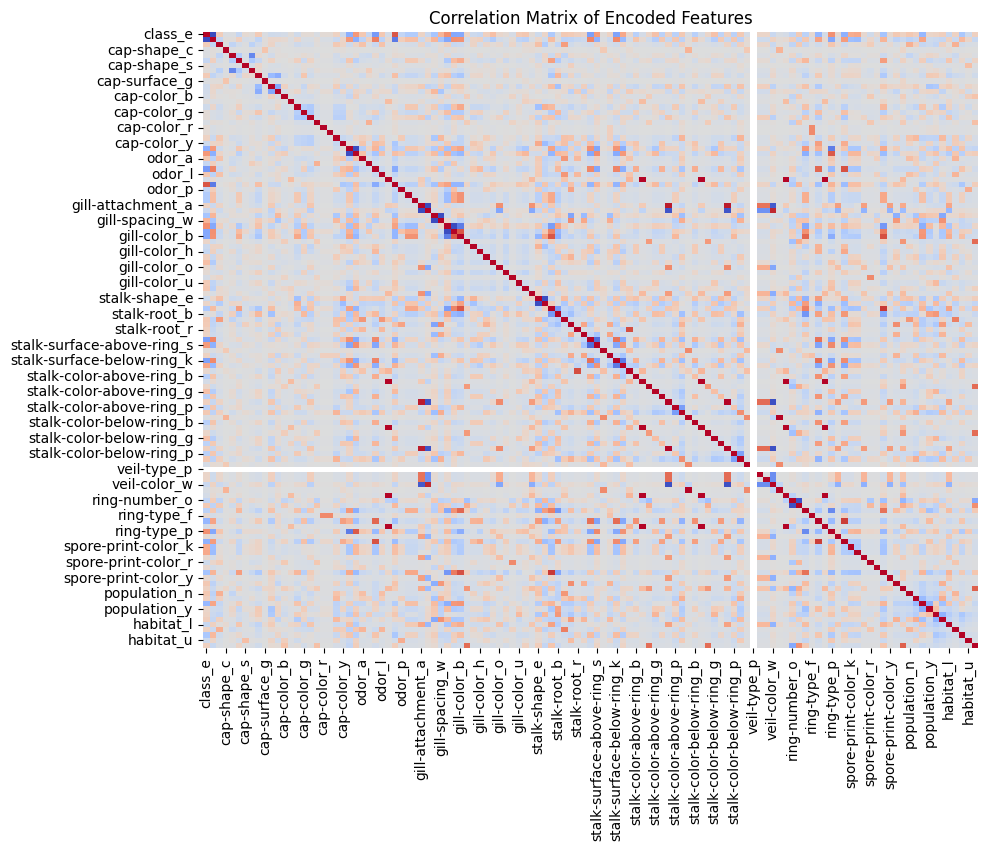

In [16]:
df_encoded = pd.get_dummies(df)
corr_matrix = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", cbar=False)
plt.title("Correlation Matrix of Encoded Features")
plt.show()


## 0.8 Missing values
We now search for missing values inside our dataset.

In [17]:
df.isnull().any(axis=0)

,0
class,False
cap-shape,False
cap-surface,False
cap-color,False
bruises,False
odor,False
gill-attachment,False
gill-spacing,False
gill-size,False
gill-color,False


We do not seem to have any missing values.
But by the documentation, we know they may be represented by the "?" symbol, so we check for it.

In [18]:
(df == "?").any()

,0
class,False
cap-shape,False
cap-surface,False
cap-color,False
bruises,False
odor,False
gill-attachment,False
gill-spacing,False
gill-size,False
gill-color,False


In the feature stalk-root we have some missing values. Let
us see how many samples do not have any value for this feature.

In [19]:
df[df["stalk-root"]=="?"]

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
3984,e,x,y,b,t,n,f,c,b,e,...,s,e,w,p,w,t,e,w,c,w
4023,p,x,y,e,f,y,f,c,n,b,...,s,w,w,p,w,o,e,w,v,p
4076,e,f,y,u,f,n,f,c,n,h,...,f,w,w,p,w,o,f,h,y,d
4100,p,x,y,e,f,y,f,c,n,b,...,s,p,p,p,w,o,e,w,v,d
4104,p,x,y,n,f,f,f,c,n,b,...,s,p,p,p,w,o,e,w,v,l
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


Since about the 30% of samples in our dataset has missing values, but just for this feature, we decide to remove the feature `stalk-root` itself.
We could already see by the countplot that "?" was the second most popular value.
Since we are working with many features, that as we already commented are not strongly correlated to this one, removing it is the best choice possible, given the high number of missing values.

In [20]:
df= df.drop(columns=["stalk-root"])
df.shape

(8124, 22)

## 0.9 Treating categorical features
As one could clearly notice by the first rows of our dataset, and as we have already underlined, all the features are categorical, meaning that they can take values only from a set of classes.
The majority of our features are nominal, i.e. there is no implied order among them (think about the different hat shapes), so for these features the one-hot encoding is the best strategy.
But regarding the *class* feature, we may interpret that as if there is an explicit order among the case edible and poisonous. It would be like ordering them based on the poisonousness level. For example we could associate to the first label the value 0 and 1 to the second one. So we treat this feature as an ordinal one.
We start to work on the latter one.






In [21]:
ordinal_encoder= OrdinalEncoder(categories=[['e','p']])
pois_level = ordinal_encoder.fit_transform(df[['class']])
pois_level= pois_level.flatten().astype(int)
df.insert(
    loc=df.columns.get_loc("class")+1,
    column="pois-level",
    value=pois_level
)
df.drop(columns="class", inplace=True)
df

,pois-level,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,0,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,0,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,1,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,0,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,0,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,0,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,1,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


Now we study all the other features.

In [22]:
nominal_features = ["cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-surface-above-ring", "stalk-surface-below-ring",
    "stalk-color-above-ring", "stalk-color-below-ring",
    "veil-type", "veil-color", "ring-number", "ring-type",
    "spore-print-color", "population", "habitat"]

nom_encoder = OneHotEncoder()
nom_features = nom_encoder.fit_transform(df[nominal_features])
nom_features = nom_features.toarray()
nom_features = pd.DataFrame(nom_features,columns=nom_encoder.get_feature_names_out(nominal_features),index=df.index)
nom_features = nom_features.astype(int)
df = pd.concat([df[["pois-level"]], nom_features],axis=1)

df


,pois-level,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,1,0,0,0,0,0,1,0,0,1,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,1,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
8120,0,0,0,0,0,0,1,0,0,1,...,0,1,0,0,0,1,0,0,0,0
8121,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
8122,1,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0


## 0.10 Splitting the dataset
The last part of this preprocessing stage is to divide our dataset into a training and a test set, that we will use respectively for training and evaluating our models.

In [23]:
target = "pois-level"

#for clustering
X = df.drop(columns=[target])
y = df[target]

#for classification
train_data, test_data, train_labels, test_labels = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=102, stratify=y)
train_data

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
3022,0,0,1,0,0,0,1,0,0,0,...,0,0,1,1,0,0,0,0,0,0
3748,0,0,1,0,0,0,1,0,0,0,...,0,1,0,1,0,0,0,0,0,0
3528,0,0,1,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,0,0
1534,0,0,1,0,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
3175,0,0,0,0,0,1,0,0,0,1,...,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1269,0,0,0,0,0,1,0,0,0,1,...,0,0,1,1,0,0,0,0,0,0
144,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
6164,0,0,0,0,0,1,0,0,1,0,...,0,1,0,1,0,0,0,0,0,0
5619,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


## **1 Clustering**
In this section, we apply different clustering techniques to explore the structure of the mushroom dataset.
Our goal is to identify natural groupings in the data and to evaluate if these groupings are consistent with the known distinction between edible and poisonous mushrooms.

Since clustering is an unsupervised learning task, the true class labels are not used during model fitting and are considered only for post evaluation.

First we here import all the libraries used for this task.

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as shc
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score

## 1.1 K-Means

We first try K-Means with 2 clusters, since this is the number of groups we ideally expect since it corresponds to the number of known classes in the dataset.

K-Means is a prototype-based clustering algorithm, based on the use of centroids.
To apply K-Means we first need to normalize our features.

In [25]:
X_scaled= StandardScaler().fit_transform(X)

In [26]:
kmeans = KMeans(n_clusters=2, random_state=42)

features = X_scaled
target=y.to_numpy()
target_predicted = kmeans.fit_predict(features)


We use the Silhouette Coefficient as an internal validation metric to assess the quality of the clustering solution in the absence of supervision.

In [27]:
silhouette_avg = silhouette_score(features, target_predicted)
print("Silhouette score:", silhouette_avg)


Silhouette score: 0.10669114093658011


To evaluate the clustering results we can also use the Adjusted Rand Index (ARI).
ARI measures the agreement between the clustering labels and the true class labels.

In [28]:
ari_kmeans = adjusted_rand_score(target, target_predicted)
print("ARI (KMeans):",ari_kmeans)

ARI (KMeans): 0.6186047146005356


The K-means clustering with k = 2 shows a low average silhouette score (0.107), indicating weak cluster compactness and poor separation in the feature space. This suggests that the data do not exhibit a strong natural clustering structure under the Euclidean distance assumption. However, the Adjusted Rand Index of 0.62 reveals a moderate agreement between the clustering solution and the true class labels.

To visually inspect the clustering structure we project the standardized feature space onto two dimensions using Principal Component Analysis (PCA).

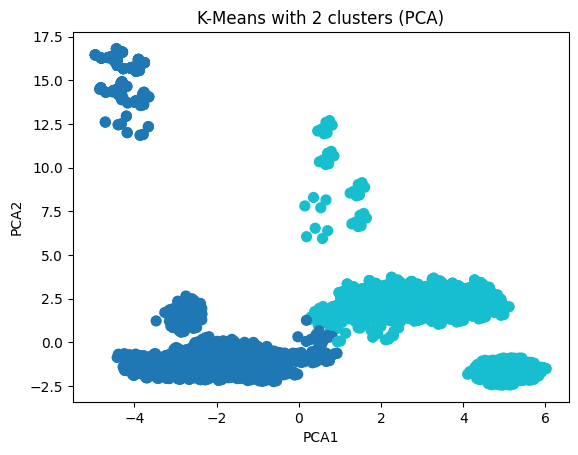

In [29]:
features_2d = PCA(n_components=2).fit_transform(features)
plt.figure()
plt.scatter(features_2d[:,0], features_2d[:,1], c=target_predicted, cmap='tab10', s=50)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('K-Means with 2 clusters (PCA)')
plt.show()

We can observe a clear division among the two clusters, especially along the first principal component. This suggests that this component is the one that mostly distinguishes between poisonous and edible mushrooms.

Moreover, as anticipated, we can notice that there is a low geometric separation of the clusters and also low cohesion, since they seem a bit sparse. This is coherent with the low silhouette score we found.

However, interpreting the value of the principal components would not be very informative, since it would depend on too many features.
Nonetheless we can try to understand the meaning of the two principal components as follows:

In [30]:
pca_2d=PCA(n_components=2)
pca_2d.fit(features)
loadings = pd.DataFrame(pca_2d.components_.T, index=X.columns, columns=['PCA1', 'PCA2'])
# Top 5 feature per PCA1
print(loadings['PCA1'].abs().sort_values(ascending=False).head(5))

# Top 5 feature per PCA2
print(loadings['PCA2'].abs().sort_values(ascending=False).head(5))

stalk-surface-above-ring_k    0.256699
stalk-surface-below-ring_k    0.255848
ring-type_p                   0.240104
odor_f                        0.223763
stalk-surface-above-ring_s    0.222336
Name: PCA1, dtype: float64
gill-attachment_f           0.281925
gill-attachment_a           0.281925
stalk-color-above-ring_o    0.274946
stalk-color-below-ring_o    0.274946
veil-color_w                0.274854
Name: PCA2, dtype: float64


As expected, both components depend on many characteristics of the mushrooms, making it impossible to associate a clear meaning to them.

Let us try to improve the clustering by changing the number of clusters, using the elbow and the silhoutte methods.

In [31]:
#ELBOW METHOD
def get_SSE(data, clustering_algorithm, max_clusters=15):
    SSE = []
    for k in range(2,max_clusters):
        model = clustering_algorithm(n_clusters=k, random_state=42)
        model.fit_predict(data)
        SSE.append(model.inertia_)
    return SSE

def plot_SSE(data, clustering_algorithm, title="", max_clusters=15):
    SSE = get_SSE(data, clustering_algorithm, max_clusters=max_clusters)
    plt.plot(range(2,max_clusters), SSE, 'bo-')
    plt.xlabel('Number of clusters')
    plt.ylabel('Sum of squared distances to centroid')
    plt.title(title)
    plt.show()
    return

#SILHOUETTE COEFFICIENTS METHOD
def get_silhouette_score(data, clustering_algorithm, max_clusters=15):
    silhouette_coefficients = []
    for k in range(2,max_clusters):
        model = clustering_algorithm(n_clusters=k, random_state=42)
        model.fit_predict(data)
        score = silhouette_score(data, model.labels_)
        silhouette_coefficients.append(score)
    return silhouette_coefficients

def plot_silhouette_score(data, clustering_algorithm, title="", max_clusters=15):
    sil_scores = get_silhouette_score(data, clustering_algorithm, max_clusters=max_clusters)
    plt.plot(range(2, max_clusters), sil_scores, 'bo-')
    plt.xlabel('Number of clusters')
    plt.ylabel('Silhouette coefficient')
    plt.title(title)
    plt.show()
    return

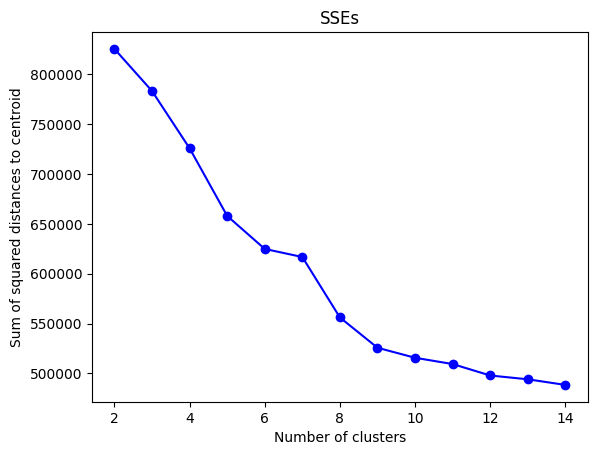

In [32]:
plot_SSE(X_scaled, KMeans, title="SSEs")

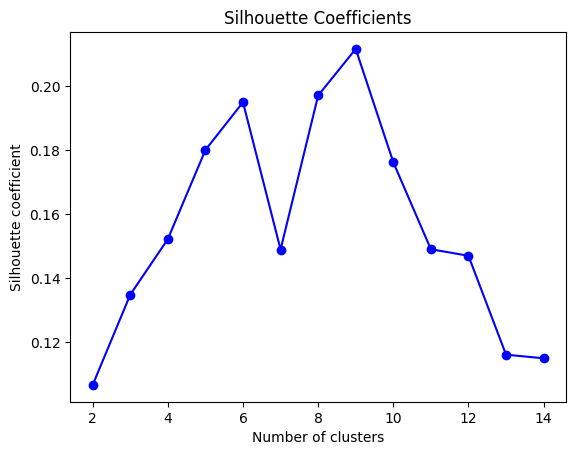

In [33]:
plot_silhouette_score(X_scaled, KMeans, title="Silhouette Coefficients")

By this two methods, the choice k=9 seems to be the best one.
We try K-Means with 9 clusters.

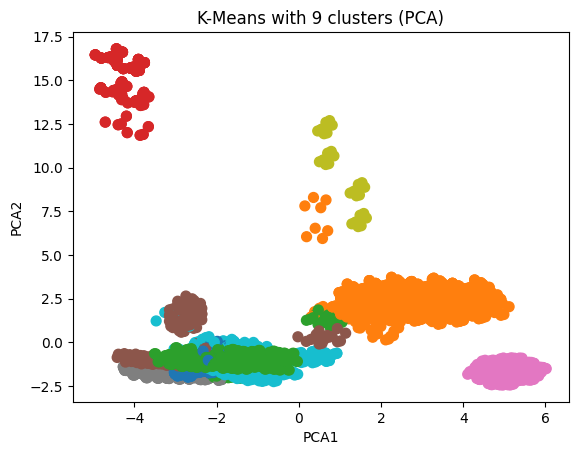

In [34]:
kmeans_9 = KMeans(n_clusters=9, random_state=42)
target_predicted_9 = kmeans_9.fit_predict(features)

plt.figure()
plt.scatter(features_2d[:,0], features_2d[:,1], c=target_predicted_9, cmap='tab10', s=50)
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('K-Means with 9 clusters (PCA)')
plt.show()

In [35]:
silhouette_9 = silhouette_score(features, target_predicted_9)
print("Silhouette score (k = 9):", silhouette_9)

Silhouette score (k = 9): 0.21153639114119696


Increasing the number of clusters to k = 9 leads to a higher silhouette score (0.21), indicating improved local compactness and separation of the clusters.

In [36]:
ari_kmeans_9 = adjusted_rand_score(target, target_predicted_9)
print("ARI (KMeans with 9 clusters):", ari_kmeans_9)

ARI (KMeans with 9 clusters): 0.2964994761168806


Even if the elbow method suggests to use k=9, the ARI value decreases. This can be related to the fact that the SSE method doesn't use the true class labels, but refers uniquely to how compact the points are inside of the clusters. On the other hand, ARI checks if points in the same clusters have the same labels: over-partitioning the dataset may provoke a decrease in this index.

## 1.2 Agglomerative clustering

As next technique, we will try to use hierarchical clustering. In particular we will focus on the agglomerative case and we start with single linkage. Again, we aim to recover 2 clusters.
First let us plot the deondogram.
Due to the large number of observations, the dendrogram is truncated to improve readability.

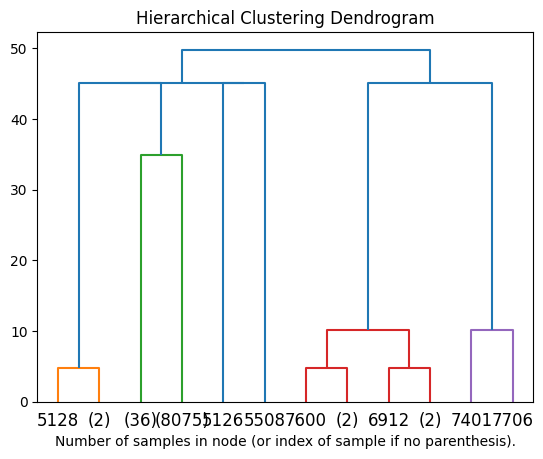

In [37]:
shc.dendrogram(shc.linkage(features, method='single'), truncate_mode='level',p=3)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Number of samples in node (or index of sample if no parenthesis).")
plt.show()

In [38]:
target=y.to_numpy()
agglomerative = AgglomerativeClustering(n_clusters=2, linkage='single')
target_predicted_agg = agglomerative.fit_predict(features)


In [39]:
silhouette_agg = silhouette_score(features, target_predicted_agg)
print("Silhouette score (Agglomerative, single, k=2):", silhouette_agg)


Silhouette score (Agglomerative, single, k=2): 0.7667772879805825


In [40]:
ari_agg = adjusted_rand_score(target, target_predicted_agg)
print("ARI(Agglomerative with single linkage):", ari_agg)

ARI(Agglomerative with single linkage): 0.00015024920403875597


Agglomerative Clustering with single linkage achieves a high silhouette coefficient (0.77), indicating strong internal cohesion and separation between clusters from a geometric perspective. However, the Adjusted Rand Index is close to zero, revealing no meaningful agreement between the obtained clusters and the true class labels.
This apparent contradiction can be explained by the chaining effect associated with single linkage: single linkage tends to create clusters by linking points through nearest neighbors, which can lead to artificially high silhouette values even when the resulting clusters do not reflect meaningful class structure.


Again, in order to visualize the result we need to reduce the features to 2 principal components.

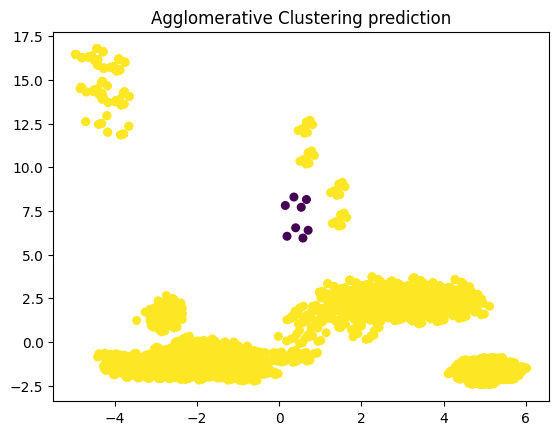

In [41]:
features_2d = PCA(n_components=2).fit_transform(features)
plt.scatter(features_2d[:,0], features_2d[:,1], c=target_predicted_agg, cmap='viridis', s=30)
plt.title("Agglomerative Clustering prediction")
plt.show()

This method doesn't see to work really well, it looks like almost all samples are merged in a unique cluster.
This can be caused by the high dimensionality of our data: the distance looses its meaning.
We could use different linkages to improve the results.

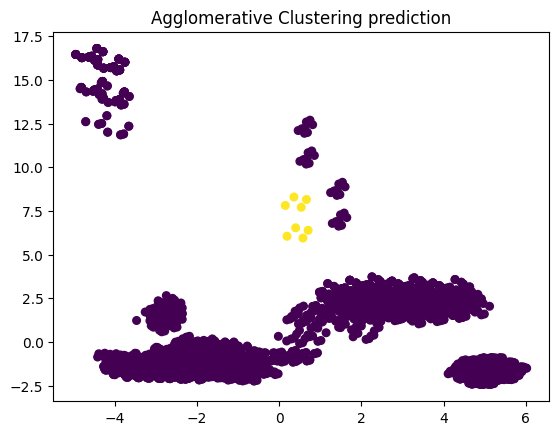

In [42]:
agg_avg = AgglomerativeClustering(n_clusters=2, linkage='average')
target_predicted_avg = agg_avg.fit_predict(features)

plt.scatter(features_2d[:,0], features_2d[:,1], c=target_predicted_avg, cmap='viridis', s=30)
plt.title("Agglomerative Clustering prediction")
plt.show()

In [43]:
silhouette_avg = silhouette_score(features, target_predicted_avg)
print("Silhouette score (Agglomerative, average, k=2):", silhouette_avg)

Silhouette score (Agglomerative, average, k=2): 0.7667772879805825


In [44]:
ari_agg_avg = adjusted_rand_score(target, target_predicted_avg)
print("ARI (Agglomerative with average linkage):", ari_agg_avg)

ARI (Agglomerative with average linkage): 0.00015024920403875597


Agglomerative Clustering with single and average linkage produces the same clustering result when k = 2. This happens because the data contains a small group of points that is clearly separated from the rest, so both linkage methods merge the observations in the same way. As a result, the silhouette score is identical and high (0.77), showing good internal separation. However, the ARI is close to zero, indicating that these clusters do not match the true class labels.

## 1.3 DBSCAN ##

An alternative density-based clustering method is DBSCAN.

Although a common theoretical rule suggests setting minPts proportional to the dimensionality, such a choice would be overly restrictive in this high-dimensional one-hot encoded dataset. Therefore, we chose a smaller and more practical value of minPts = 10.

To select a suitable value for ε (eps), we use the k-distance plot with minPts = 10.  
The plot shows the distance to the 10th nearest neighbor for each data point, sorted in ascending order.

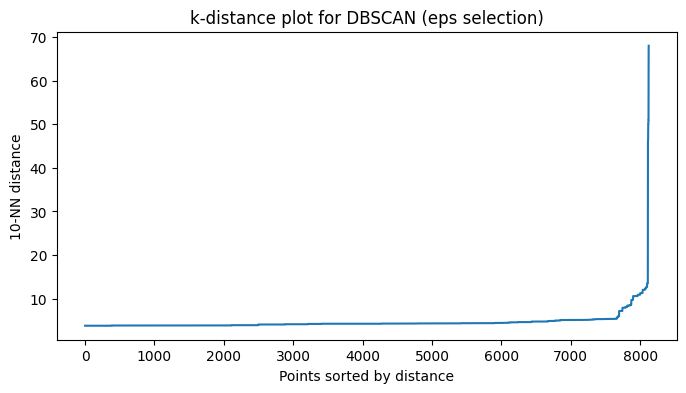

In [45]:
minPts= 10
features = X_scaled

nbrs = NearestNeighbors(n_neighbors=minPts)
nbrs_fit = nbrs.fit(features)

distances, indices = nbrs_fit.kneighbors(features)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{minPts}-NN distance")
plt.title("k-distance plot for DBSCAN (eps selection)")
plt.show()


The eps we're intrested in belongs to the interval (0,10). To choose it properly we give a closer look at the graph. From the zoomed k-distance plot, we can clearly observe three regions.  



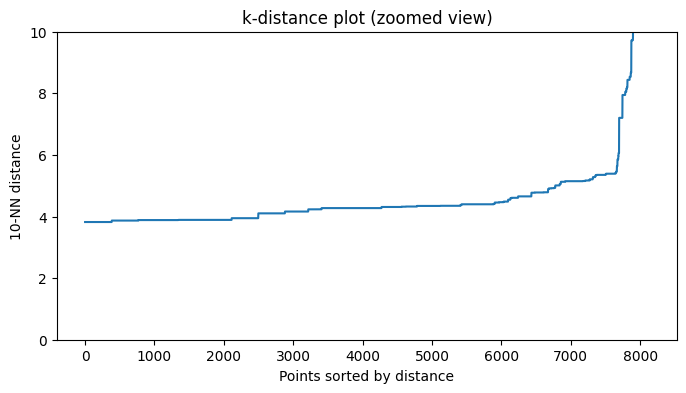

In [46]:
plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.ylim(0, 10)
plt.xlabel("Points sorted by distance")
plt.ylabel("10-NN distance")
plt.title("k-distance plot (zoomed view)")
plt.show()


First, the curve is almost flat, corresponding to points located in dense areas.  
Then, between values around 5 and 7, the curve shows a clear change in slope.  
After this point, the distance increases sharply, indicating sparse points and potential noise.

Since the elbow of the curve is not a single exact value but a small interval, ε = 6 is selected as a reasonable compromise just before the steep increase.

In [47]:
eps = 6

dbscan = DBSCAN(eps=eps, min_samples=minPts)
target_predicted_db = dbscan.fit_predict(features)

n_clusters = len(set(target_predicted_db)) - (1 if -1 in target_predicted_db else 0)
n_noise = np.sum(target_predicted_db == -1)

print("Number of clusters found:", n_clusters)
print("Number of noise points:", n_noise)

Number of clusters found: 35
Number of noise points: 428


After selecting ε = 6 and minPts = 10 based on the k-distance plot, we apply DBSCAN applied to the scaled data.  
DBSCAN identifies 35 clusters and 428 noise points.  
Unlike K-Means, DBSCAN does not impose a predefined number of clusters and tends to split the data into multiple dense regions.

In order to use the silhouette coefficient to assest the quality of our clustering, here we need to do an intermediate step. In fact the silhouette coefficient is defined only for points assigned to a valid cluster, but DBSCAN is not complete and explicitly labels noise points as −1. Therefore these observations must be excluded from the computation to obtain a meaningful silhouette value.

In [48]:
mask = target_predicted_db != -1

if len(set(target_predicted_db[mask])) > 1:
    silhouette_dbscan = silhouette_score(features[mask], target_predicted_db[mask])
    print("Silhouette score (DBSCAN, excluding noise):", silhouette_dbscan)
else:
    print("Silhouette score cannot be computed (less than 2 clusters)")

Silhouette score (DBSCAN, excluding noise): 0.27546408557974783


In [49]:
ari_dbscan = adjusted_rand_score(target, target_predicted_db)
print("Adjusted Rand Index (DBSCAN):", ari_dbscan)



Adjusted Rand Index (DBSCAN): 0.2643444514583651


DBSCAN achieves a moderate silhouette score (0.27), indicating that the detected dense regions have limited internal cohesion and separation. The low Adjusted Rand Index (0.26) further shows that the density-based clusters do not align well with the true class labels.

##Conclusions
Overall, K-Means outperforms both Agglomerative Clustering and DBSCAN in terms of agreement with the true class labels.  
This indicates that the dataset is better described by a global partitioning approach rather than by hierarchical or density-based clustering methods, and that we can assume that our clusters have globular shapes.

By the theory we know that an advanced method, such as SNN, would probably perform better since we have an high number of dimensions.